--------------------------------------------------
📊 EDA Report: smart_198_raw vs s198_damaged
🔗 피어슨 상관계수(r): 0.120 (p-value: 0.0000)
--------------------------------------------------


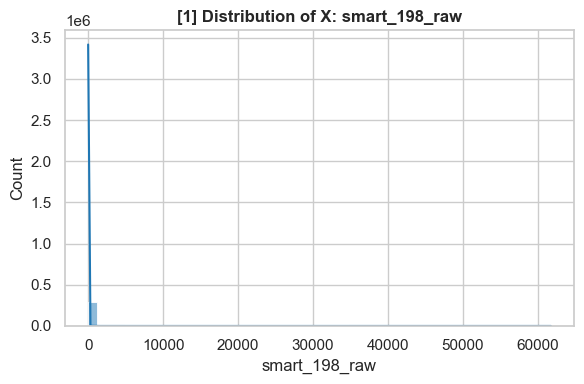

C:\Users\joon6\AppData\Local\Temp\ipykernel_10872\1385781218.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_data, palette='Set2')


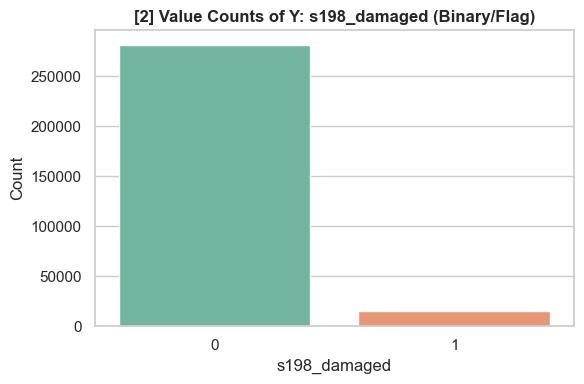

C:\Users\joon6\AppData\Local\Temp\ipykernel_10872\1385781218.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_data, x=y_col, y=x_col, palette='Set2')


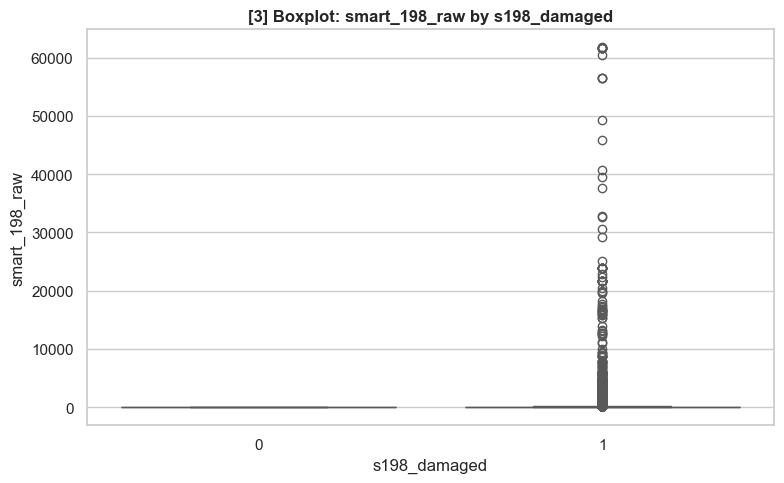


[상세 통계량]
                    mean         std min    max   skewness     kurtosis
feature                                                                
smart_198_raw  14.409572  522.834106   0  61744  84.253615  8539.795412
s198_damaged    0.050176    0.218308   0      1   4.121032    14.983008

--------------------------------------------------
📊 EDA Report: smart_9_raw vs smart_241_raw
🔗 피어슨 상관계수(r): 0.890 (p-value: 0.0000)
--------------------------------------------------


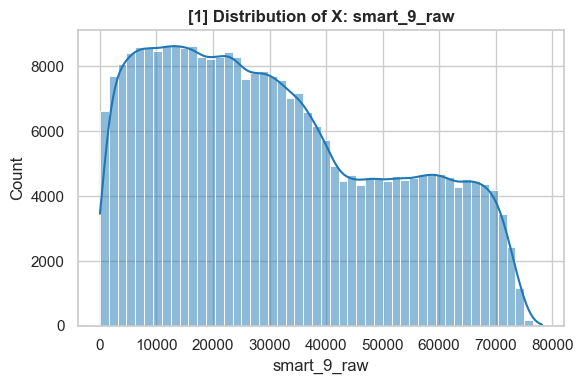

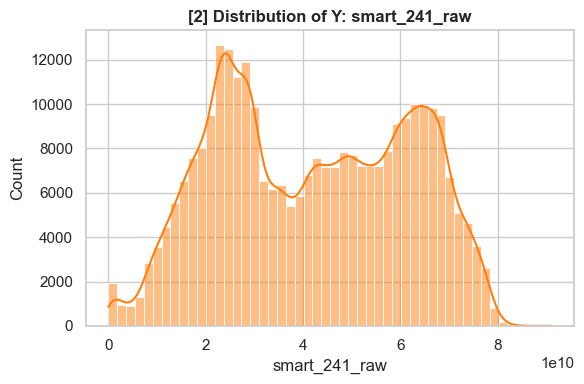

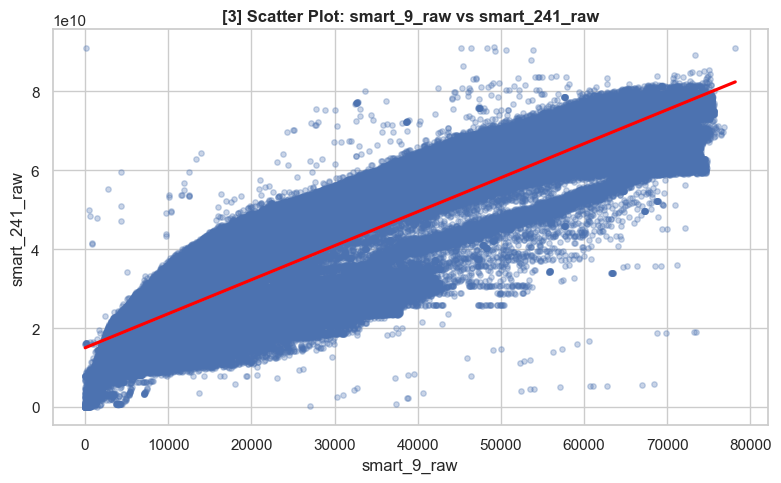


[상세 통계량]
                       mean           std  min          max  skewness  \
feature                                                                 
smart_9_raw    3.124966e+04  2.027688e+04    6        78175  0.385021   
smart_241_raw  4.193524e+10  1.963808e+10    0  91109530197  0.011553   

               kurtosis  
feature                  
smart_9_raw   -0.960977  
smart_241_raw -1.181118  



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import duckdb

def analyze_feature_pair_separated(df: pd.DataFrame, x_col: str, y_col: str):
    """
    두 변수의 개별 분포와 관계를 각각 3개의 분리된 그래프로 출력합니다.
    Y변수가 이진형(0,1)인지 연속형인지 자동으로 판별하여 알맞은 그래프를 그립니다.
    """
    # 1. 결측치 제어
    valid_data = df[[x_col, y_col]].dropna()
    x_data = valid_data[x_col]
    y_data = valid_data[y_col]

    # 2. 통계량 및 상관계수 계산 (분산 0 에러 방어 포함)
    if x_data.std() == 0 or y_data.std() == 0:
        print(f"⚠️ 경고: '{x_col}' 또는 '{y_col}'의 값이 모두 동일합니다.")
        corr, p_value = 0.0, 1.0  
    else:
        corr, p_value = stats.pearsonr(x_data, y_data)
    
    stats_df = pd.DataFrame({
        'feature': [x_col, y_col],
        'mean': [x_data.mean(), y_data.mean()],
        'std': [x_data.std(), y_data.std()],
        'min': [x_data.min(), y_data.min()],
        'max': [x_data.max(), y_data.max()],
        'skewness': [x_data.skew(), y_data.skew()],
        'kurtosis': [x_data.kurtosis(), y_data.kurtosis()]
    }).set_index('feature')

    sns.set_theme(style="whitegrid")
    
    print("-" * 50)
    print(f"📊 EDA Report: {x_col} vs {y_col}")
    print(f"🔗 피어슨 상관계수(r): {corr:.3f} (p-value: {p_value:.4f})")
    print("-" * 50)

    # ==========================================
    # [그래프 1] X 변수의 개별 분포 (히스토그램)
    # ==========================================
    plt.figure(figsize=(6, 4))
    sns.histplot(x_data, kde=True, color='#1f77b4', bins=50)
    plt.title(f"[1] Distribution of X: {x_col}", weight='bold')
    plt.xlabel(x_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # [그래프 2] Y 변수의 개별 분포
    # ==========================================
    plt.figure(figsize=(6, 4))
    is_y_binary = y_data.nunique() <= 2  # 고유값이 2개 이하인지 확인

    if is_y_binary:
        # 이진형(0, 1) 플래그 변수인 경우 막대 그래프
        sns.countplot(x=y_data, palette='Set2')
        plt.title(f"[2] Value Counts of Y: {y_col} (Binary/Flag)", weight='bold')
    else:
        # 연속형 숫자 변수인 경우 히스토그램
        sns.histplot(y_data, kde=True, color='#ff7f0e', bins=50)
        plt.title(f"[2] Distribution of Y: {y_col}", weight='bold')
    
    plt.xlabel(y_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # ==========================================
    # [그래프 3] X와 Y의 관계
    # ==========================================
    plt.figure(figsize=(8, 5))
    if is_y_binary:
        # Y가 이진형이면 '박스플롯' (정상 vs 고장 그룹 간 X값 차이 비교)
        sns.boxplot(data=valid_data, x=y_col, y=x_col, palette='Set2')
        plt.title(f"[3] Boxplot: {x_col} by {y_col}", weight='bold')
    else:
        # Y가 연속형이면 '산점도' (추세선 포함)
        sns.regplot(data=valid_data, x=x_col, y=y_col, 
                    scatter_kws={'alpha': 0.3, 's': 15}, 
                    line_kws={'color': 'red'})
        plt.title(f"[3] Scatter Plot: {x_col} vs {y_col}", weight='bold')
    
    plt.tight_layout()
    plt.show()

    return stats_df

# ==========================================
# 🚀 실행 코드
# ==========================================
train_path = r'..\data\fs_sample_data\fs_sample_train.parquet'
X_train = duckdb.query(f"SELECT * FROM '{train_path}'").df()

feature_pairs = [
    ('smart_198_raw', 's198_damaged'), # 연속형 vs 이진형 테스트
]

for x_feat, y_feat in feature_pairs:
    stats_df = analyze_feature_pair_separated(df=X_train, x_col=x_feat, y_col=y_feat)
    print("\n[상세 통계량]")
    print(stats_df)
    print("=" * 60 + "\n")